# Machine Learning Assignment 2

**Objective:** Train and compare five classifiers using Logistic Regression, Decision Tree,
k-Nearest Neighbors, Gaussian Naive Bayes, and Random Forest (Ensemble) on the Dry Bean Dataset to classify a bean sample into one of seven registered varieties from 19 computer-vision-derived shape/size features, scored
with Accuracy, AUC, Precision, Recall, F1 and MCC.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RNG_SEED = 42

In [3]:
from ucimlrepo import fetch_ucirepo
dry_bean = fetch_ucirepo(id=602)
df = dry_bean.data.features.copy()
df['Class'] = dry_bean.data.targets['Class']
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Dataset size, missing values, duplicates and feature types

In [4]:
print(f"Shape: {df.shape}")
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.info()

Shape: (13611, 17)

Missing values:
 0

Duplicate rows: 68
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class     

In [5]:
# Drop exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (13543, 17)


**Observation:** The raw dataset has no missing values, but contains 68 exact duplicate
rows (13,611 --> 13,543 after dedup) likely repeated feature extractions from very similar
bean images. All 16 base features are numeric, so no categorical encoding is required for the raw features.

## Class Distribution

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


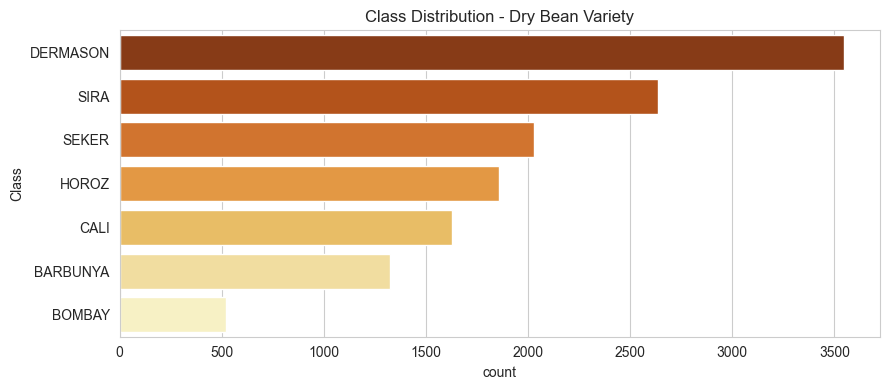

In [6]:
print(df['Class'].value_counts())
plt.figure(figsize=(9, 4))
sns.countplot(y='Class', data=df, order=df['Class'].value_counts().index, palette='YlOrBr_r')
plt.title('Class Distribution - Dry Bean Variety')
plt.tight_layout()
plt.show()

**Observation:** The dataset is moderately imbalanced. Dermason is the majority class
while Bombay is a clear minority but Bombay beans
are visually very distinct (much larger), so this imbalance is unlikely to hurt any model
badly. We use stratify=y in the train/test split and weighted-average metrics to keep
the comparison fair across classes.

## Correlation structure

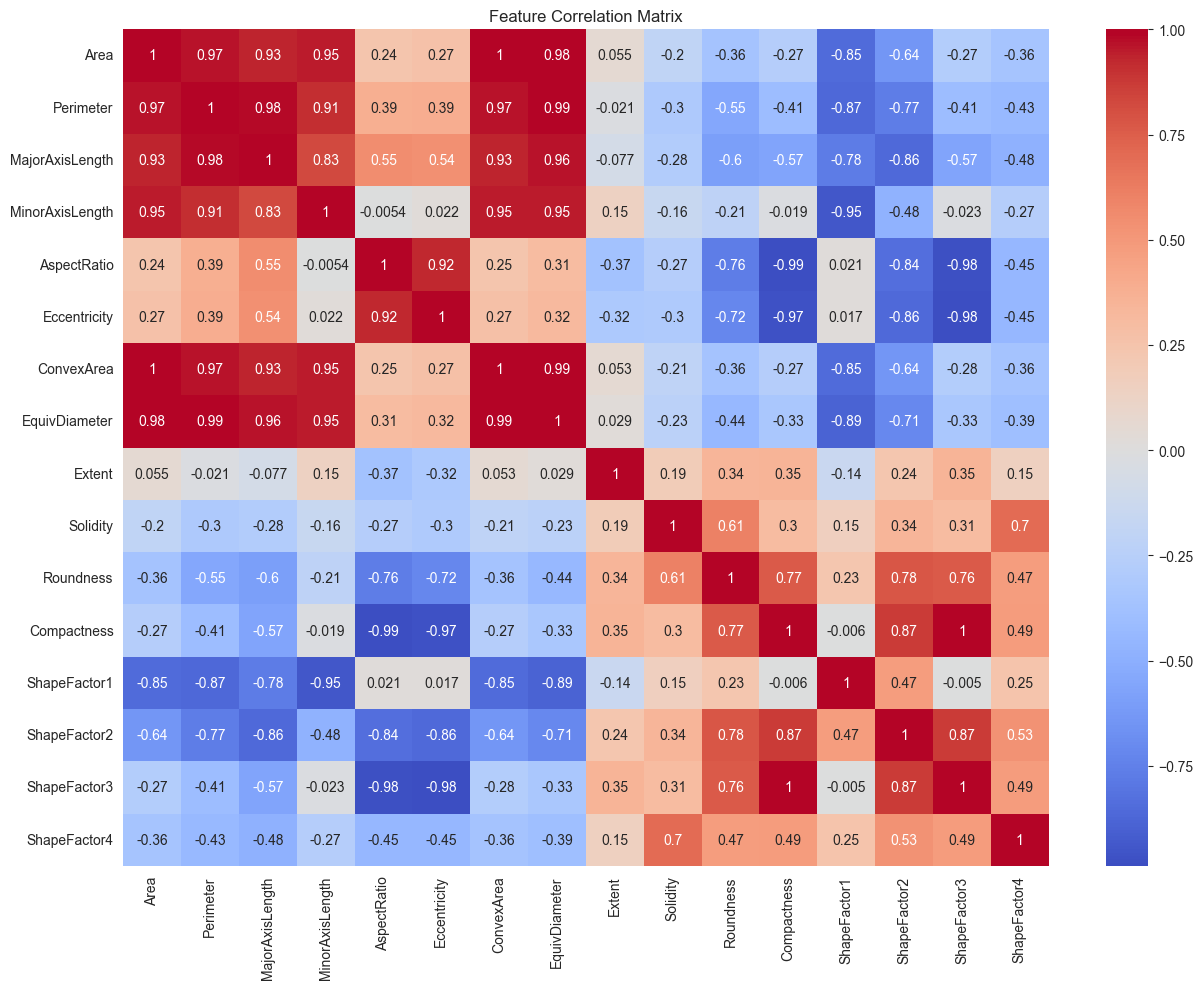

In [7]:
plt.figure(figsize=(13, 10))
sns.heatmap(df.drop(columns=['Class']).corr(), cmap='coolwarm', center=0, annot=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** As expected for shape-derived measurements, Area, Perimeter,
ConvexArea, EquivDiameter, MajorAxisLength and MinorAxisLength are all very
highly correlated with each other since they all scale with the physical size of the
bean. ShapeFactor1–4 and Compactness/Roundness/AspectRatio/Eccentricity
capture the *shape* of the bean independently of its size, which is what lets the
models separate visually similar-sized varieties. This heavy size-feature redundancy is
exactly the kind of correlation that tends to hurt Naive Bayes the most, since it
assumes conditional feature independence.

## Feature distributions

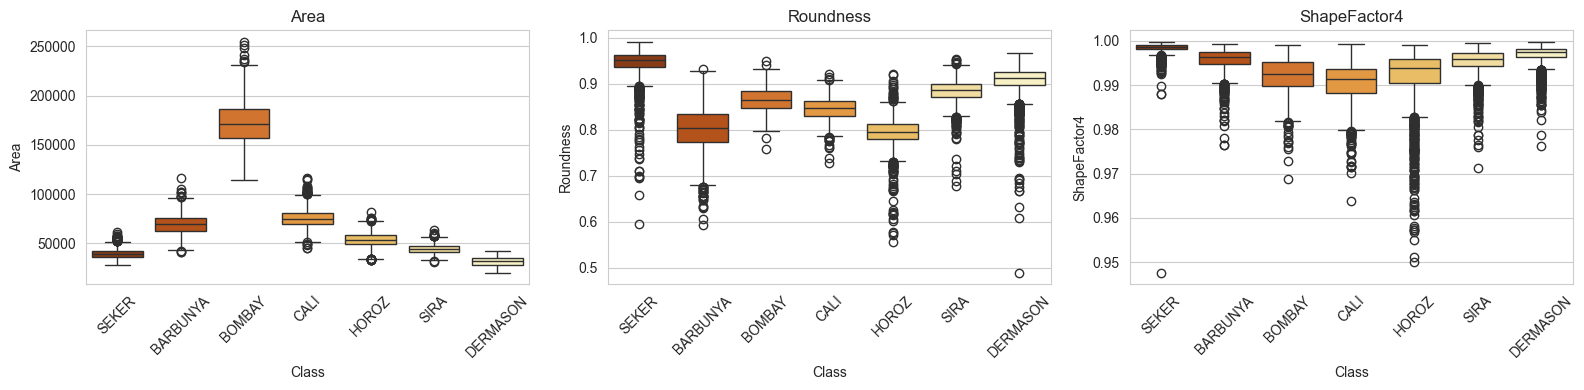

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Area', 'Roundness', 'ShapeFactor4']):
    sns.boxplot(data=df, x='Class', y=col, ax=ax, palette='YlOrBr_r')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Bombay beans separate almost perfectly on Area alone - they are
roughly 3–4x larger than any other variety. Roundness clearly distinguishes
Seker/Sira (rounder) from Barbunya/Horoz (more elongated). ShapeFactor4 shows
tighter, more overlapping distributions across classes, meaning it likely contributes
less discriminative power on its own than the size- and roundness-based features.

## Feature engineering

In [9]:
'''ConvexityDeficit = (ConvexArea − Area) / ConvexArea - how much a bean's outline deviates from its
 convex hull (0 = perfectly convex, higher = more irregular/concave outline)'''
df['ConvexityDeficit'] = (df['ConvexArea'] - df['Area']) / df['ConvexArea']

'''AreaPerimeterRatio = Area / Perimeter - an alternative compactness proxy that
  behaves differently from Roundness because it is not squared/normalized the same way.'''
df['AreaPerimeterRatio'] = df['Area'] / df['Perimeter']

'''DiameterRatio = EquivDiameter / MajorAxisLength - how close to circular vs.
  elongated a bean's silhouette is.'''
df['DiameterRatio'] = df['EquivDiameter'] / df['MajorAxisLength']

df[['ConvexityDeficit', 'AreaPerimeterRatio', 'DiameterRatio']].describe()

,ConvexityDeficit,AreaPerimeterRatio,DiameterRatio
count,13543.000000,13543.000000,13543.000000
mean,0.012848,58.886606,0.800352
std,0.004650,13.064219,0.061464
min,0.005323,34.347608,0.640577
25%,0.009981,51.428441,0.763228
50%,0.011712,55.988882,0.801514
75%,0.014322,62.744563,0.834470
max,0.080754,131.820900,0.987303


## Label Encode

In [10]:
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['Class'])
class_names = label_encoder.classes_
print("Classes:", list(class_names))

feature_cols = [c for c in df.columns if c not in ('Class', 'target')]
print(f"Total feature count: {len(feature_cols)}")
print(feature_cols)

X = df[feature_cols]
y = df['target']

Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Total feature count: 19
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'ConvexityDeficit', 'AreaPerimeterRatio', 'DiameterRatio']


## Train / test split


In [11]:
# 80/20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 10834
Test samples: 2709


## Train the five model pipelines

In [12]:
pipelines = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                      ("clf", LogisticRegression(max_iter=3000, random_state=RNG_SEED))]),
    "Decision Tree": Pipeline([("scaler", StandardScaler()),
                                ("clf", DecisionTreeClassifier(max_depth=10, random_state=RNG_SEED))]),
    "kNN": Pipeline([("scaler", StandardScaler()),
                      ("clf", KNeighborsClassifier(n_neighbors=9))]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()),
                              ("clf", GaussianNB())]),
    "Random Forest (Ensemble)": Pipeline([("scaler", StandardScaler()),
                                           ("clf", RandomForestClassifier(n_estimators=300, max_depth=14, random_state=RNG_SEED))]),
}

results = []
trained_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        'ML Model Name': name, 'Accuracy': round(acc, 4), 'AUC': round(auc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1': round(f1, 4), 'MCC': round(mcc, 4)
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.91      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.93      0.91       326
    DERMASON       0.90      0.91      0.90       709
       HOROZ       0.96      0.92      0.94       372
       SEKER       0.93      0.93      0.9

## Comparison table

In [13]:
model_scores = pd.DataFrame(results)
model_scores

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9188,0.9935,0.9193,0.9188,0.9189,0.9019
1,Decision Tree,0.9048,0.9644,0.9052,0.9048,0.9049,0.8848
2,kNN,0.9144,0.9851,0.9151,0.9144,0.9144,0.8964
3,Naive Bayes,0.8952,0.9898,0.8979,0.8952,0.8953,0.8740
4,Random Forest (Ensemble),0.9166,0.9926,0.9167,0.9166,0.9165,0.8991


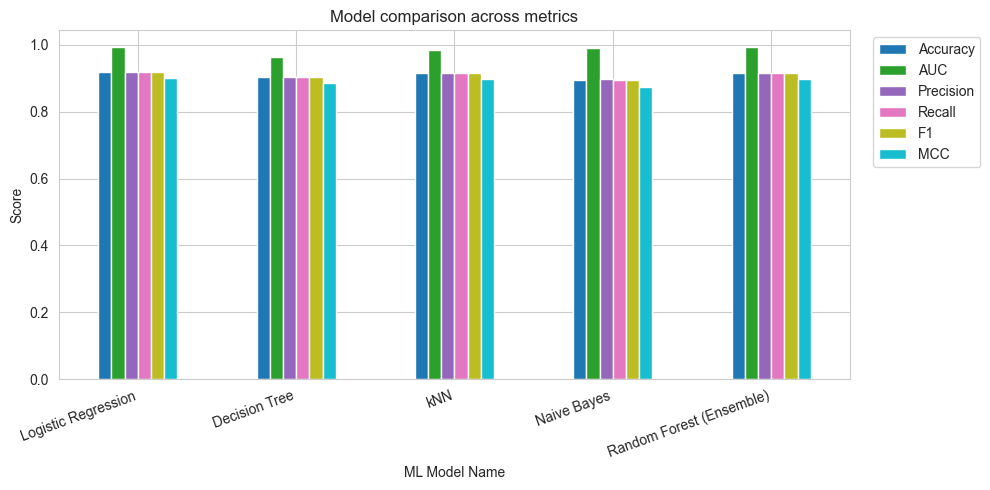

In [14]:
model_scores.set_index('ML Model Name')[['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']].plot(
    kind='bar', figsize=(10, 5), colormap='tab10'
)
plt.title('Model comparison across metrics')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix for best-performing model

Best model (by MCC): Logistic Regression


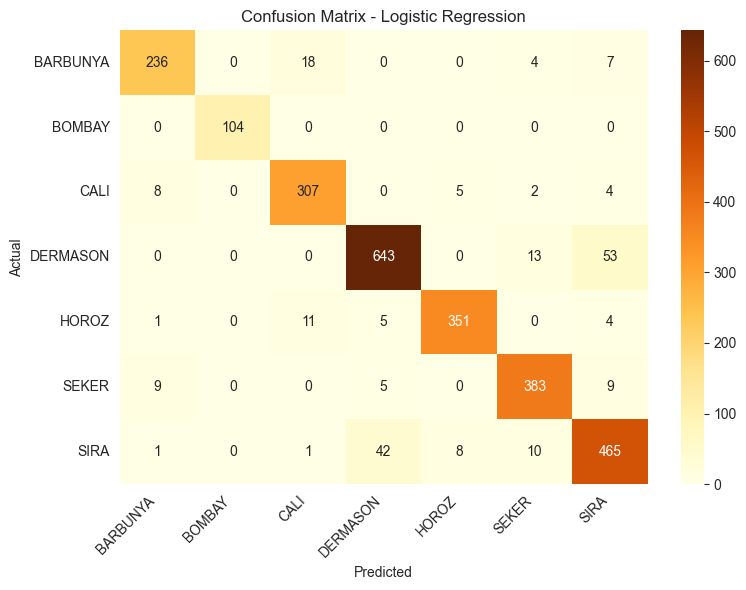

In [15]:
best_model_name = model_scores.sort_values('MCC', ascending=False).iloc[0]['ML Model Name']
print("Best model (by MCC):", best_model_name)

best_pipeline = trained_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observation
The confusion matrix is heavily diagonal. Almost all of the confusion sits between
Sira and Dermason, and between Barbunya and Cali - pairs of varieties that are
similar in size and shape. Bombay is essentially never confused with anything else,
consistent with its clearly separated Area distribution seen earlier.

## Models, metadata, and the evaluation split

In [16]:
import pickle
from pathlib import Path

MODEL_DIR = Path(".")

for name, pipe in trained_models.items():
    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"
    with open(MODEL_DIR / fname, "wb") as fh:
        pickle.dump(pipe, fh)

with open(MODEL_DIR / "label_encoder.pkl", "wb") as fh:
    pickle.dump(label_encoder, fh)
with open(MODEL_DIR / "feature_columns.pkl", "wb") as fh:
    pickle.dump(feature_cols, fh)

test_export = df.loc[X_test.index, feature_cols + ['Class']].copy()
test_export.to_csv("../test_data.csv", index=False)

print("Saved 5 pipelines and metadata to model/, and test_data.csv with", test_export.shape[0], "rows")

Saved 5 pipelines and metadata to model/, and test_data.csv with 2709 rows
